✅ Libraries imported successfully
✅ Data loaded successfully!
   Best Algorithm: DBSCAN
   Clusters: 2
   Customers: 5,878

📊 CUSTOMER SEGMENT PROFILES


,Cluster,Segment Type,Size,Percentage,Avg Recency,Avg Frequency,Avg Monetary,Total Revenue,Revenue %
0,0,💎 Regular Spenders,5690,99.89,204.79,5.33,1957.72,11139405.00,99.99
1,1,👤 One-Time Buyers,6,0.11,4.00,1.00,214.13,1284.80,0.01


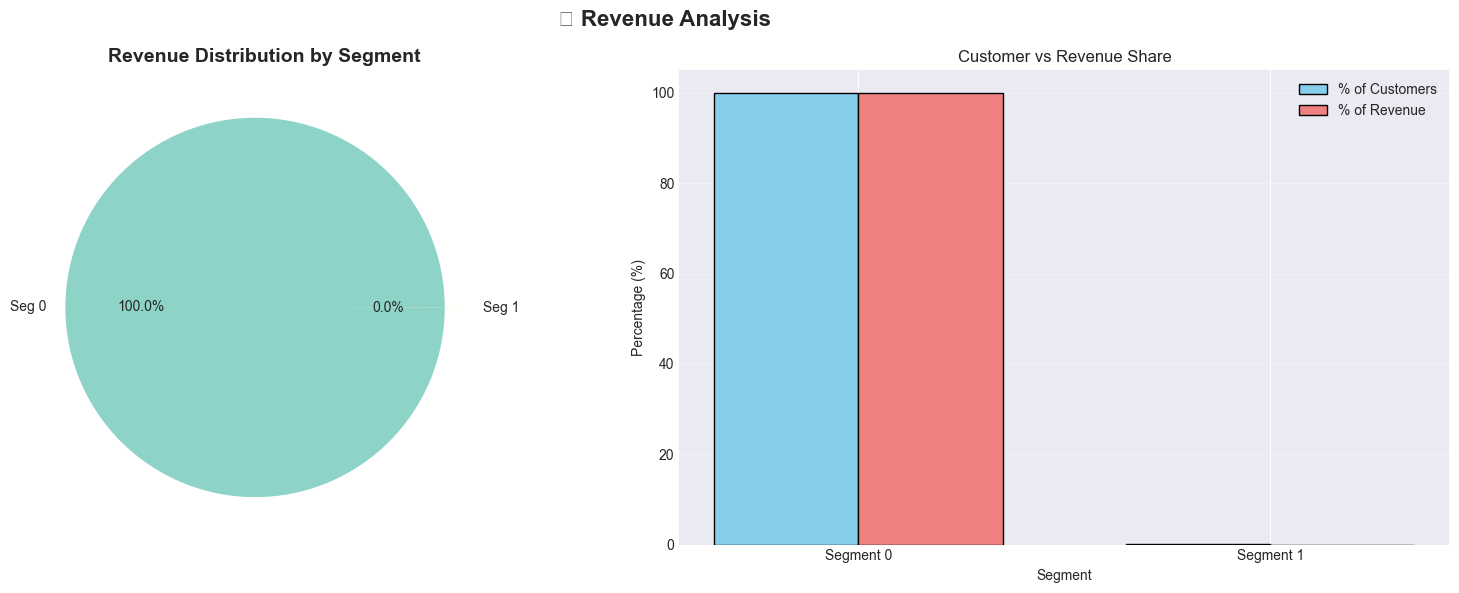


💰 HIGHEST REVENUE SEGMENT: Segment 0
   Type: 💎 Regular Spenders
   Revenue: 100.0% of total

⚠️ CHURN RISK BY SEGMENT (%)


Churn_Risk,Low,Medium-Low,Medium,Medium-High,High
Cluster,,,,,
0,26.80,12.90,8.60,10.20,41.50
1,100.00,0.00,0.00,0.00,0.00


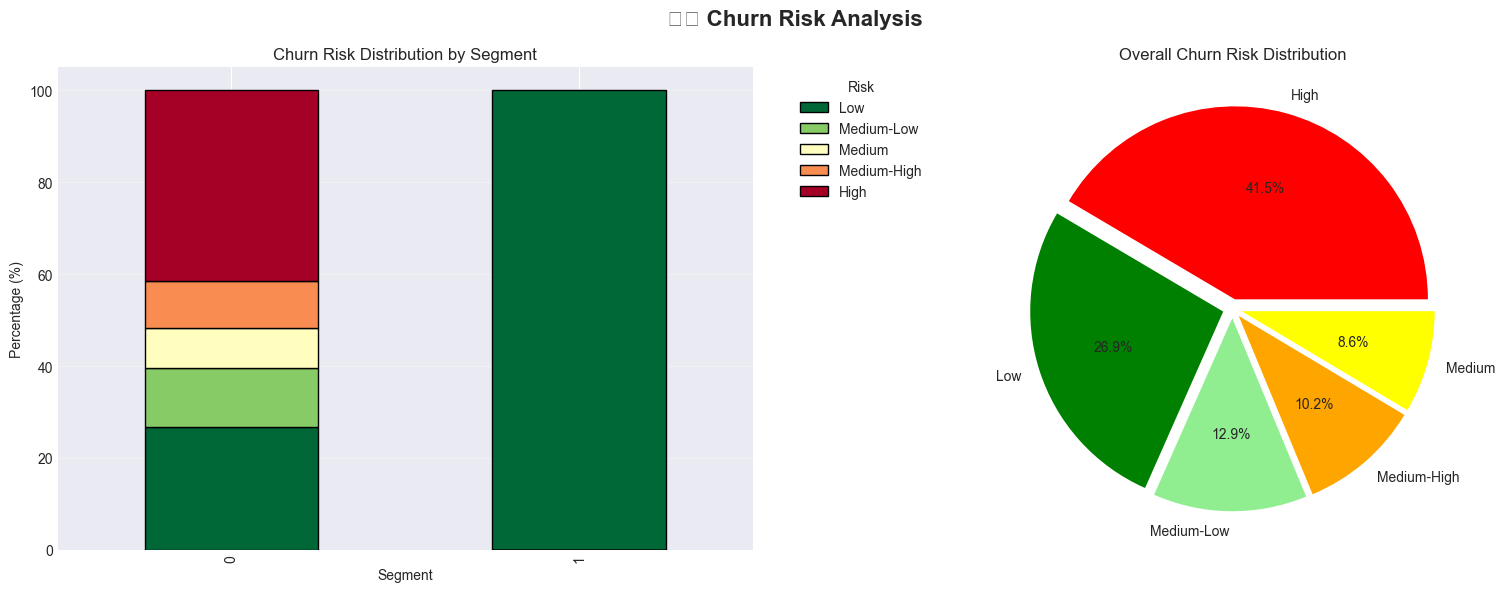


⚠️ At-Risk Customers: 2944 (51.7%)

📢 MARKETING STRATEGY RECOMMENDATIONS


,Segment,Type,Channel,Offer,Frequency,Goal,Priority
0,0,💎 Regular Spenders,"Email, App Notifications","Volume discounts, Loyalty points",Bi-weekly,Increase frequency,📈 High
1,1,👤 One-Time Buyers,"Email, Newsletters",Seasonal promotions,Monthly,Increase engagement,📋 Low


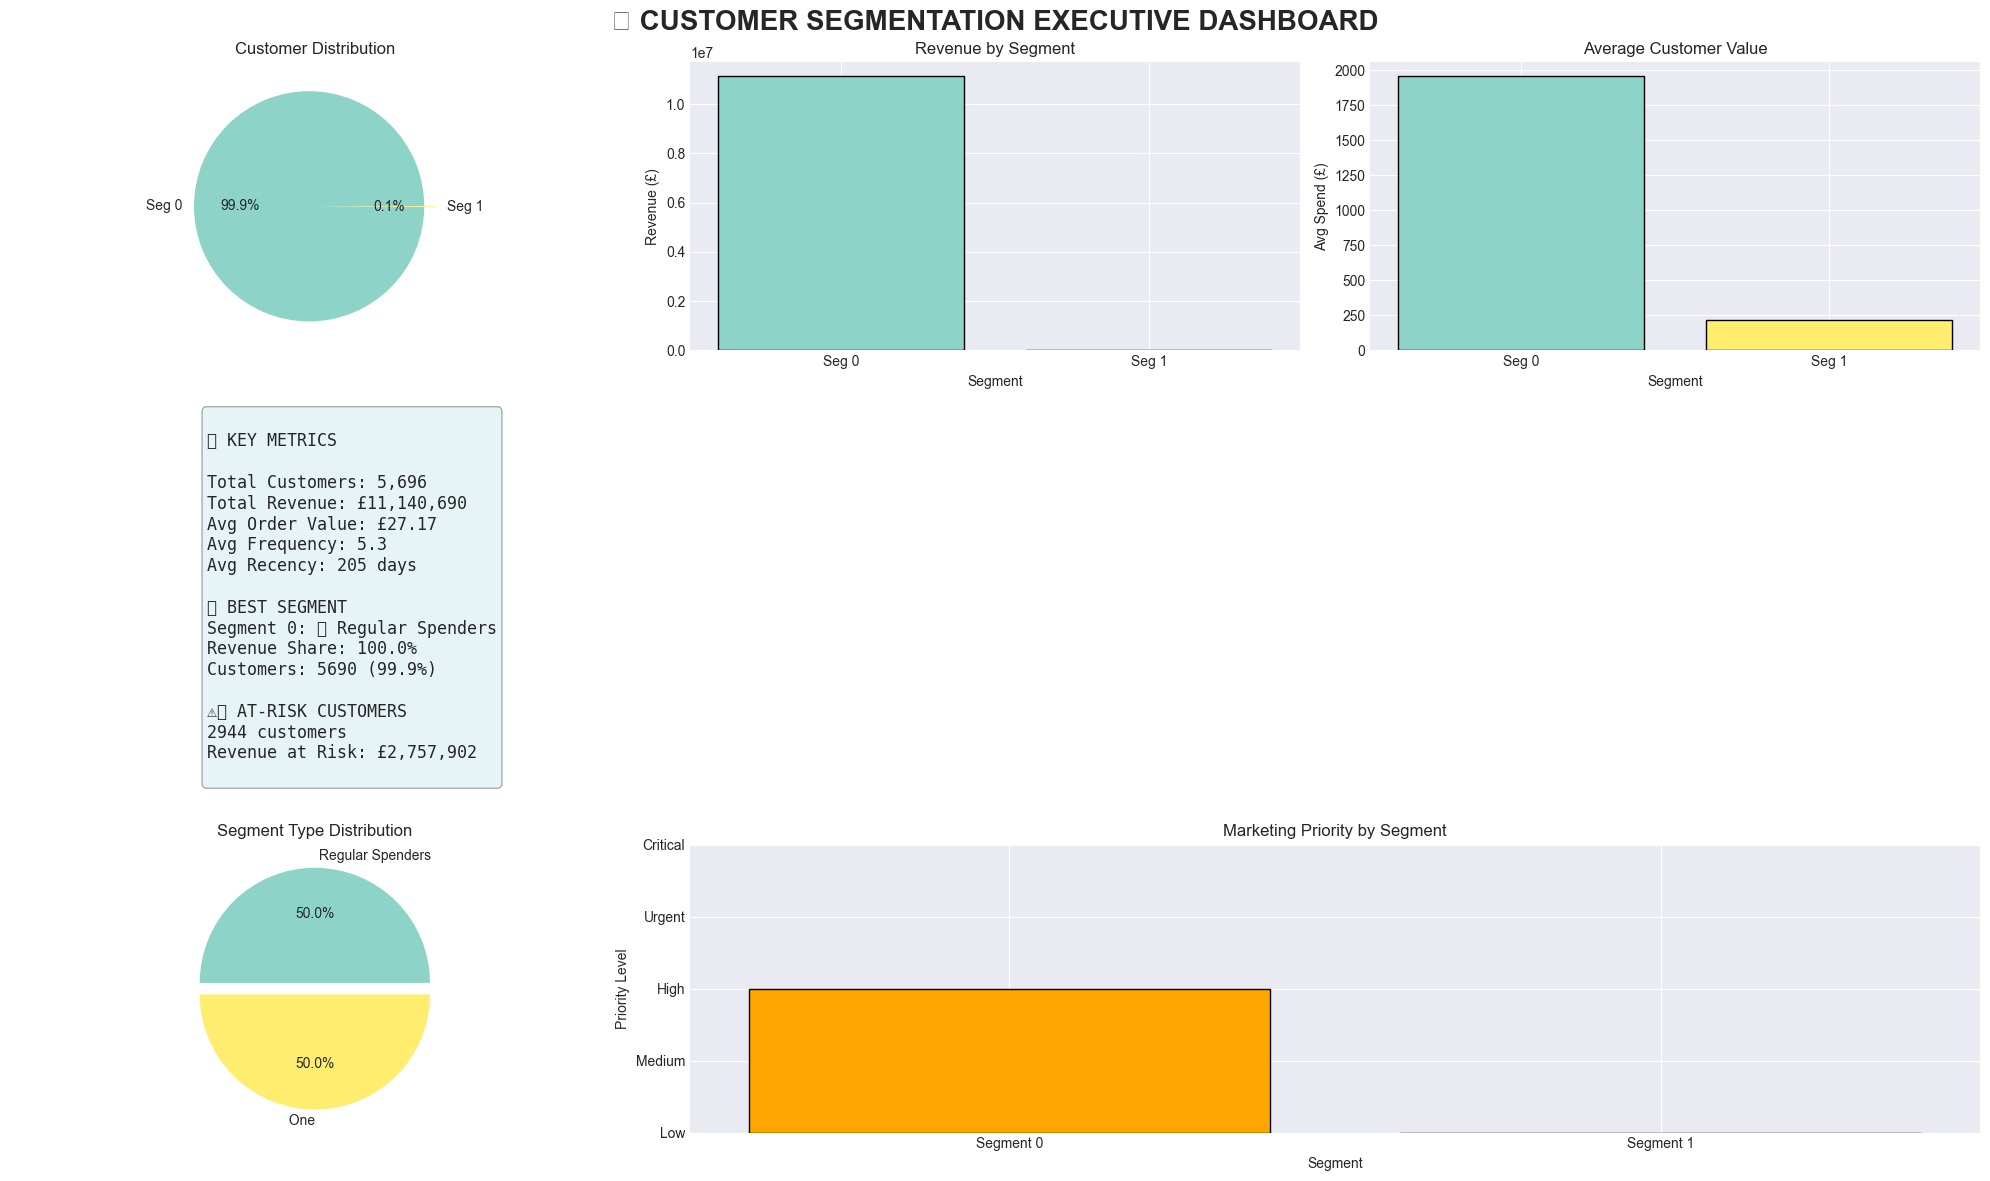


🎯 CUSTOMER SEGMENTATION PROJECT - COMPLETED

✅ Project Statistics:
   • Dataset: Online Retail II
   • Cleaned Records: 805,549
   • Unique Customers: 5,696

🧠 Algorithms Implemented:
   • K-Means Clustering
   • Hierarchical Clustering
   • DBSCAN
   • Gaussian Mixture Model

🏆 Best Model: DBSCAN
   • Optimal Clusters: 2
   • Silhouette Score: 0.5512
   • Quality Grade: A

📊 Business Value:
   • Identified 2 distinct customer segments
   • Highest value segment: 💎 Regular Spenders
   • Revenue at risk: £2,757,902

📁 Output Files Generated:
   • data/processed/cleaned_data.csv
   • data/processed/customer_features.csv
   • results/cluster_assignments.csv
   • results/metrics/segment_profiles.csv
   • results/metrics/marketing_strategies.csv
   • results/cluster_plots/*.png

✅ PROJECT COMPLETED SUCCESSFULLY!


In [1]:
# %% [markdown]
# # 📊 06 - Business Insights and Visualization
# ## Customer Segmentation Project

# %% [markdown]
# ### Import Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Libraries imported successfully")

# %% [markdown]
# ### Load Data

# %%
# Load data
customer_features = pd.read_csv('../data/processed/customer_features.csv')
cluster_assignments = pd.read_csv('../results/cluster_assignments.csv')

# Load best model
with open('../results/metrics/final_model_selection.json', 'r') as f:
    best_model = json.load(f)

best_algo = best_model['best_algorithm']
best_clusters = best_model['n_clusters']

# Get labels for best algorithm
labels = cluster_assignments[f'{best_algo}_Cluster'].values

# Merge data
df = customer_features.copy()
df['Cluster'] = labels

print(f"✅ Data loaded successfully!")
print(f"   Best Algorithm: {best_algo}")
print(f"   Clusters: {best_clusters}")
print(f"   Customers: {len(df):,}")

# Remove noise if any
if -1 in df['Cluster'].values:
    df_clean = df[df['Cluster'] != -1].copy()
else:
    df_clean = df.copy()

# %% [markdown]
# ## 1️⃣ Customer Segment Profiles

# %%
def create_segment_profiles(df):
    """Create profiles for each segment"""
    profiles = []
    
    for cluster in sorted(df['Cluster'].unique()):
        cluster_data = df[df['Cluster'] == cluster]
        
        size = len(cluster_data)
        pct = (size / len(df)) * 100
        
        # Calculate metrics
        avg_recency = cluster_data['Recency'].mean() if 'Recency' in cluster_data.columns else 0
        avg_frequency = cluster_data['Frequency'].mean() if 'Frequency' in cluster_data.columns else 0
        avg_monetary = cluster_data['Monetary'].mean() if 'Monetary' in cluster_data.columns else 0
        total_revenue = cluster_data['Monetary'].sum() if 'Monetary' in cluster_data.columns else 0
        revenue_pct = (total_revenue / df['Monetary'].sum()) * 100 if 'Monetary' in df.columns else 0
        
        # Determine segment type
        if avg_monetary > df['Monetary'].quantile(0.75) and avg_frequency > df['Frequency'].quantile(0.75):
            segment_type = "🏆 High-Value Loyalists"
        elif avg_monetary > df['Monetary'].quantile(0.5) and avg_frequency > df['Frequency'].quantile(0.5):
            segment_type = "💎 Regular Spenders"
        elif avg_recency > 90 and avg_monetary > 0:
            segment_type = "⚠️ At-Risk Customers"
        elif avg_frequency > 3 and avg_monetary < df['Monetary'].median():
            segment_type = "🛒 Budget Shoppers"
        elif avg_frequency == 1:
            segment_type = "👤 One-Time Buyers"
        else:
            segment_type = "📦 Occasional Buyers"
        
        profiles.append({
            'Cluster': cluster,
            'Segment Type': segment_type,
            'Size': size,
            'Percentage': pct,
            'Avg Recency': avg_recency,
            'Avg Frequency': avg_frequency,
            'Avg Monetary': avg_monetary,
            'Total Revenue': total_revenue,
            'Revenue %': revenue_pct
        })
    
    return pd.DataFrame(profiles)

# Create profiles
segment_profiles = create_segment_profiles(df_clean)
segment_profiles = segment_profiles.sort_values('Avg Monetary', ascending=False).reset_index(drop=True)

print("\n📊 CUSTOMER SEGMENT PROFILES")
print("=" * 100)
display(segment_profiles.round(2))

# Save profiles
segment_profiles.to_csv('../results/metrics/segment_profiles.csv', index=False)

# %% [markdown]
# ## 2️⃣ Revenue Analysis

# %%
# Revenue analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Revenue pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_profiles)))
wedges, texts, autotexts = ax1.pie(segment_profiles['Total Revenue'],
                                     labels=[f'Seg {int(c)}' for c in segment_profiles['Cluster']],
                                     autopct='%1.1f%%', colors=colors,
                                     explode=[0.05] * len(segment_profiles))
ax1.set_title('Revenue Distribution by Segment', fontsize=14, fontweight='bold')

# Revenue vs Customer count
x = np.arange(len(segment_profiles))
width = 0.35

ax2.bar(x - width/2, segment_profiles['Percentage'], width, label='% of Customers',
        color='skyblue', edgecolor='black')
ax2.bar(x + width/2, segment_profiles['Revenue %'], width, label='% of Revenue',
        color='lightcoral', edgecolor='black')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Customer vs Revenue Share')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Segment {int(c)}' for c in segment_profiles['Cluster']])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('💰 Revenue Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Highest revenue segment
top_idx = segment_profiles['Revenue %'].idxmax()
top_segment = segment_profiles.loc[top_idx]

print(f"\n💰 HIGHEST REVENUE SEGMENT: Segment {int(top_segment['Cluster'])}")
print(f"   Type: {top_segment['Segment Type']}")
print(f"   Revenue: {top_segment['Revenue %']:.1f}% of total")

# %% [markdown]
# ## 3️⃣ Churn Risk Analysis

# %%
# Define churn risk
def calculate_churn_risk(df):
    if 'Recency' in df.columns:
        df['Churn_Risk'] = pd.cut(
            df['Recency'],
            bins=[0, 30, 60, 90, 180, float('inf')],
            labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High']
        )
    return df

df_clean = calculate_churn_risk(df_clean)

if 'Churn_Risk' in df_clean.columns:
    # Churn by segment
    churn_by_segment = pd.crosstab(
        df_clean['Cluster'],
        df_clean['Churn_Risk'],
        normalize='index'
    ) * 100
    
    print("\n⚠️ CHURN RISK BY SEGMENT (%)")
    print("=" * 70)
    display(churn_by_segment.round(1))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    churn_by_segment.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r',
                          edgecolor='black')
    axes[0].set_xlabel('Segment')
    axes[0].set_ylabel('Percentage (%)')
    axes[0].set_title('Churn Risk Distribution by Segment')
    axes[0].legend(title='Risk', bbox_to_anchor=(1.05, 1))
    axes[0].grid(True, alpha=0.3, axis='y')
    
    overall_risk = df_clean['Churn_Risk'].value_counts()
    risk_colors = {'Low': 'green', 'Medium-Low': 'lightgreen', 'Medium': 'yellow',
                   'Medium-High': 'orange', 'High': 'red'}
    colors = [risk_colors[risk] for risk in overall_risk.index]
    
    axes[1].pie(overall_risk.values, labels=overall_risk.index,
                autopct='%1.1f%%', colors=colors, explode=[0.05] * len(overall_risk))
    axes[1].set_title('Overall Churn Risk Distribution')
    
    plt.suptitle('⚠️ Churn Risk Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/churn_risk.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # At-risk customers
    at_risk = df_clean[df_clean['Churn_Risk'].isin(['High', 'Medium-High'])]
    print(f"\n⚠️ At-Risk Customers: {len(at_risk)} ({len(at_risk)/len(df_clean)*100:.1f}%)")

# %% [markdown]
# ## 4️⃣ Marketing Recommendations

# %%
def generate_marketing_strategies(segment_profiles):
    """Generate marketing strategies for each segment"""
    strategies = []
    
    for _, segment in segment_profiles.iterrows():
        cluster = int(segment['Cluster'])
        segment_type = segment['Segment Type']
        
        if "High-Value" in segment_type:
            strategy = {
                'Segment': cluster,
                'Type': '🏆 High-Value Loyalists',
                'Channel': 'Email, SMS, Direct Mail',
                'Offer': 'Premium discounts, Early access, VIP events',
                'Frequency': 'Weekly',
                'Goal': 'Retain and upsell',
                'Priority': '🔥 Critical'
            }
        elif "Regular" in segment_type:
            strategy = {
                'Segment': cluster,
                'Type': '💎 Regular Spenders',
                'Channel': 'Email, App Notifications',
                'Offer': 'Volume discounts, Loyalty points',
                'Frequency': 'Bi-weekly',
                'Goal': 'Increase frequency',
                'Priority': '📈 High'
            }
        elif "At-Risk" in segment_type:
            strategy = {
                'Segment': cluster,
                'Type': '⚠️ At-Risk Customers',
                'Channel': 'Email, Retargeting',
                'Offer': 'Win-back offers, Special discounts',
                'Frequency': 'Monthly',
                'Goal': 'Re-engage',
                'Priority': '🚨 Urgent'
            }
        elif "Budget" in segment_type:
            strategy = {
                'Segment': cluster,
                'Type': '🛒 Budget Shoppers',
                'Channel': 'Email, Social Media',
                'Offer': 'Bulk discounts, Clearance alerts',
                'Frequency': 'Bi-weekly',
                'Goal': 'Increase basket size',
                'Priority': '💰 Medium'
            }
        else:
            strategy = {
                'Segment': cluster,
                'Type': segment_type,
                'Channel': 'Email, Newsletters',
                'Offer': 'Seasonal promotions',
                'Frequency': 'Monthly',
                'Goal': 'Increase engagement',
                'Priority': '📋 Low'
            }
        
        strategies.append(strategy)
    
    return pd.DataFrame(strategies)

# Generate strategies
marketing_strategies = generate_marketing_strategies(segment_profiles)

print("\n📢 MARKETING STRATEGY RECOMMENDATIONS")
print("=" * 100)
display(marketing_strategies)

marketing_strategies.to_csv('../results/metrics/marketing_strategies.csv', index=False)

# %% [markdown]
# ## 5️⃣ Executive Dashboard

# %%
# Create executive dashboard
fig = plt.figure(figsize=(20, 12))
fig.suptitle('📊 CUSTOMER SEGMENTATION EXECUTIVE DASHBOARD', 
             fontsize=20, fontweight='bold', y=0.98)

# 1. Segment Size Pie Chart
ax1 = plt.subplot(3, 3, 1)
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_profiles)))
wedges, texts, autotexts = ax1.pie(segment_profiles['Percentage'],
                                     labels=[f'Seg {int(c)}' for c in segment_profiles['Cluster']],
                                     autopct='%1.1f%%', colors=colors,
                                     explode=[0.05] * len(segment_profiles))
ax1.set_title('Customer Distribution')

# 2. Revenue by Segment
ax2 = plt.subplot(3, 3, 2)
bars = ax2.bar(range(len(segment_profiles)), segment_profiles['Total Revenue'],
               color=colors, edgecolor='black')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Revenue (£)')
ax2.set_title('Revenue by Segment')
ax2.set_xticks(range(len(segment_profiles)))
ax2.set_xticklabels([f'Seg {int(c)}' for c in segment_profiles['Cluster']])

# 3. Average Monetary Value
ax3 = plt.subplot(3, 3, 3)
bars = ax3.bar(range(len(segment_profiles)), segment_profiles['Avg Monetary'],
               color=colors, edgecolor='black')
ax3.set_xlabel('Segment')
ax3.set_ylabel('Avg Spend (£)')
ax3.set_title('Average Customer Value')
ax3.set_xticks(range(len(segment_profiles)))
ax3.set_xticklabels([f'Seg {int(c)}' for c in segment_profiles['Cluster']])

# 4. Key Metrics Summary
ax4 = plt.subplot(3, 3, (4, 6))
ax4.axis('off')
summary_text = f"""
📈 KEY METRICS

Total Customers: {len(df_clean):,}
Total Revenue: £{df_clean['Monetary'].sum():,.0f}
Avg Order Value: £{df_clean['AvgOrderValue'].mean():.2f}
Avg Frequency: {df_clean['Frequency'].mean():.1f}
Avg Recency: {df_clean['Recency'].mean():.0f} days

🏆 BEST SEGMENT
Segment {int(top_segment['Cluster'])}: {top_segment['Segment Type']}
Revenue Share: {top_segment['Revenue %']:.1f}%
Customers: {top_segment['Size']} ({top_segment['Percentage']:.1f}%)

⚠️ AT-RISK CUSTOMERS
{len(at_risk) if 'at_risk' in dir() else 0} customers
Revenue at Risk: £{(at_risk['Monetary'].sum() if 'at_risk' in dir() else 0):,.0f}
"""
ax4.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

# 5. Segment Type Distribution
ax5 = plt.subplot(3, 3, 7)
type_counts = segment_profiles['Segment Type'].str.extract(r'([A-Za-z\s]+)').iloc[:,0].value_counts()
colors_type = plt.cm.Set3(np.linspace(0, 1, len(type_counts)))
ax5.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=colors_type, explode=[0.05] * len(type_counts))
ax5.set_title('Segment Type Distribution')

# 6. Marketing Priority
ax6 = plt.subplot(3, 3, (8, 9))
priority_map = {'🔥 Critical': 4, '🚨 Urgent': 3, '📈 High': 2, '💰 Medium': 1, '📋 Low': 0}
priority_data = marketing_strategies.copy()
priority_data['Priority_Value'] = priority_data['Priority'].map(priority_map)

colors_priority = ['darkred' if p == '🔥 Critical' else 'red' if p == '🚨 Urgent'
                   else 'orange' if p == '📈 High' else 'yellow' if p == '💰 Medium'
                   else 'lightgreen' for p in priority_data['Priority']]

bars = ax6.bar(range(len(priority_data)), priority_data['Priority_Value'],
               color=colors_priority, edgecolor='black')
ax6.set_xlabel('Segment')
ax6.set_ylabel('Priority Level')
ax6.set_title('Marketing Priority by Segment')
ax6.set_xticks(range(len(priority_data)))
ax6.set_xticklabels([f'Segment {int(s)}' for s in priority_data['Segment']])
ax6.set_yticks(range(5))
ax6.set_yticklabels(['Low', 'Medium', 'High', 'Urgent', 'Critical'])

plt.tight_layout()
plt.savefig('../results/cluster_plots/executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## ✅ Project Summary

# %%
print("\n" + "="*70)
print("🎯 CUSTOMER SEGMENTATION PROJECT - COMPLETED")
print("="*70)

print(f"\n✅ Project Statistics:")
print(f"   • Dataset: Online Retail II")
print(f"   • Cleaned Records: {len(pd.read_csv('../data/processed/cleaned_data.csv')):,}")
print(f"   • Unique Customers: {len(df_clean):,}")

print(f"\n🧠 Algorithms Implemented:")
print(f"   • K-Means Clustering")
print(f"   • Hierarchical Clustering")
print(f"   • DBSCAN")
print(f"   • Gaussian Mixture Model")

print(f"\n🏆 Best Model: {best_algo}")
print(f"   • Optimal Clusters: {best_clusters}")
print(f"   • Silhouette Score: {best_model['silhouette_score']:.4f}")
print(f"   • Quality Grade: {best_model['quality_grade']}")

print(f"\n📊 Business Value:")
print(f"   • Identified {len(segment_profiles)} distinct customer segments")
print(f"   • Highest value segment: {top_segment['Segment Type']}")
print(f"   • Revenue at risk: £{at_risk['Monetary'].sum() if 'at_risk' in dir() else 0:,.0f}")

print(f"\n📁 Output Files Generated:")
print(f"   • data/processed/cleaned_data.csv")
print(f"   • data/processed/customer_features.csv")
print(f"   • results/cluster_assignments.csv")
print(f"   • results/metrics/segment_profiles.csv")
print(f"   • results/metrics/marketing_strategies.csv")
print(f"   • results/cluster_plots/*.png")

print("\n" + "="*70)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)